# Import Kaggle file

This is the only way i could manage to import the Json file, straggled at first

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"simphiwebusakwe","key":"954e3adb236fe4c75a0d31f16e2d40ce"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle --version

Kaggle CLI 2.0.1


In [ ]:
!kaggle datasets list | head

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                              Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          10598        228                1  
nalisha/job-salary-prediction-dataset                       Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          14806        327                1  
rosemeenshaikh/op-rated-tv-shows-from-tmdb                  Top Rated TV Shows from TMDB                            335625  2026-04-20 09:10:56.430000            575         27                1  
mubashirsidiki/stude

Now to work on downloading the dataset

In [ ]:
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 27.8MB/s]



In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


In [ ]:
!ls /content

insurance.csv  insurance.zip  sample_data


# Setting up our environment


In [ ]:
import pandas as pd

df = pd.read_csv("/content/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Data handling
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Exploritory Data Analysis (EDA)

In [ ]:
# check the size
df.shape

(1338, 7)

In [ ]:
# sum() counts how many duplicate rows exist

num_duplicates = df.duplicated().sum()
num_duplicates

np.int64(1)

In [ ]:
# Display the duplicate rows for inspection

duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
# Remove duplicate rows while keeping the first occurrence

df = df.drop_duplicates(keep='first')

In [ ]:
# Confirm no duplicates remain
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for Nulls
missing_values = df.isnull().sum()
display(pd.DataFrame(missing_values, columns=['Null values']))

,Null values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Display a summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
# Display descriptive statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


## Visualizing Feature Distributions

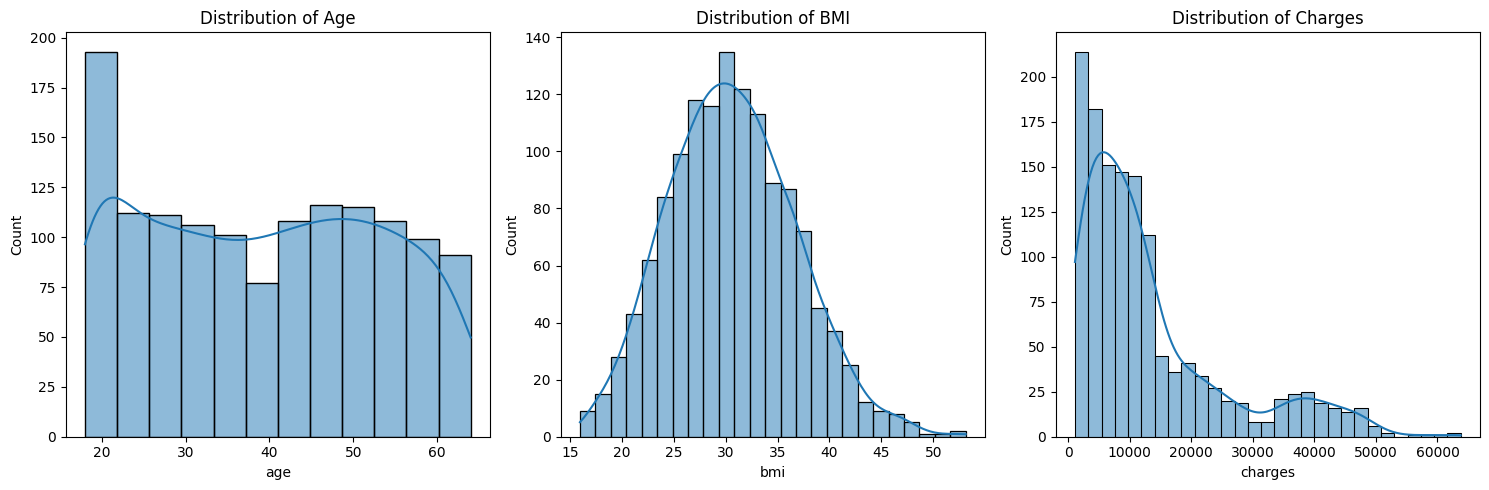

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(15, 5))

# Distribution of 'age'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')

# Distribution of 'bmi'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
sns.histplot(df['bmi'], kde=True)
plt.title('Distribution of BMI')

# Distribution of 'charges'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')

plt.tight_layout()
plt.show()

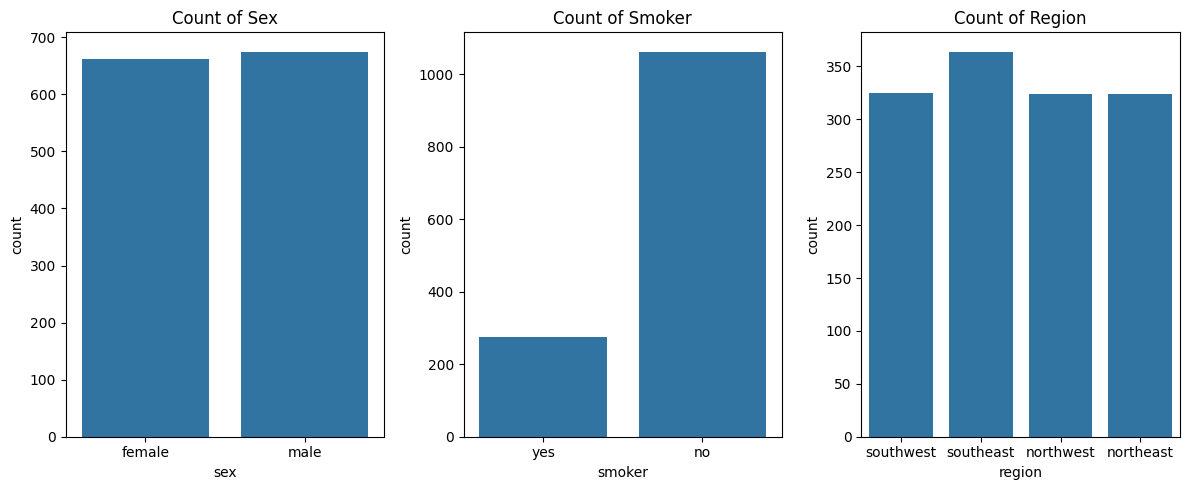

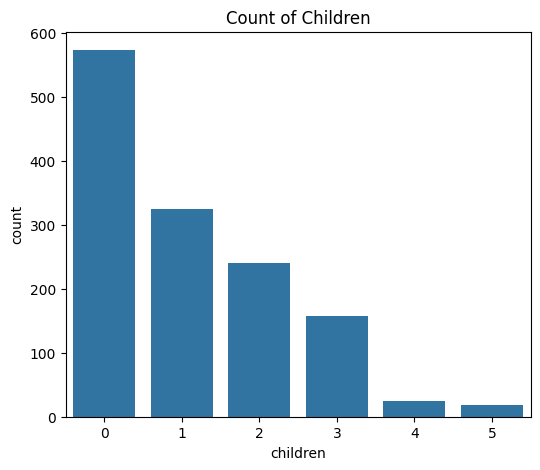

In [ ]:
# Count plot for 'sex'
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
sns.countplot(x='sex', data=df)
plt.title('Count of Sex')

# Count plot for 'smoker'
plt.subplot(1, 3, 2)
sns.countplot(x='smoker', data=df)
plt.title('Count of Smoker')

# Count plot for 'region'
plt.subplot(1, 3, 3)
sns.countplot(x='region', data=df)
plt.title('Count of Region')

plt.tight_layout()
plt.show()

# Count plot for 'children'
plt.figure(figsize=(6, 5))
sns.countplot(x='children', data=df)
plt.title('Count of Children')
plt.show()

## Relationships with Insurance Charges

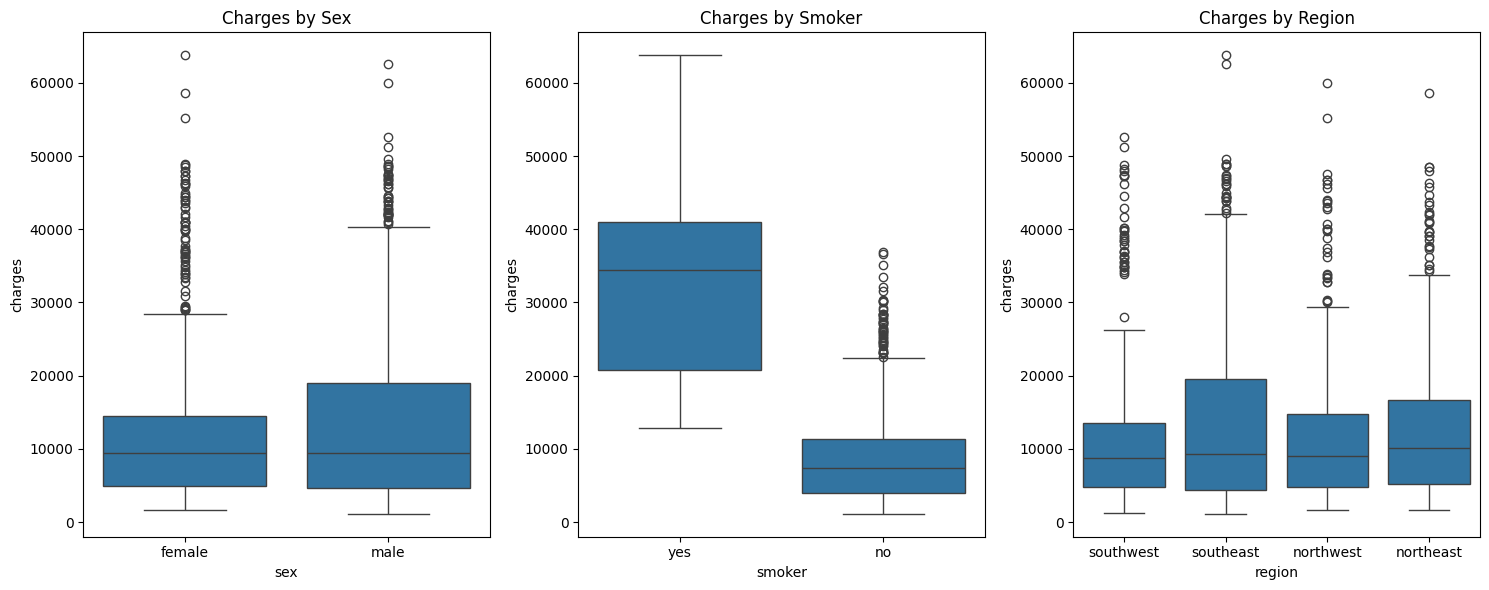

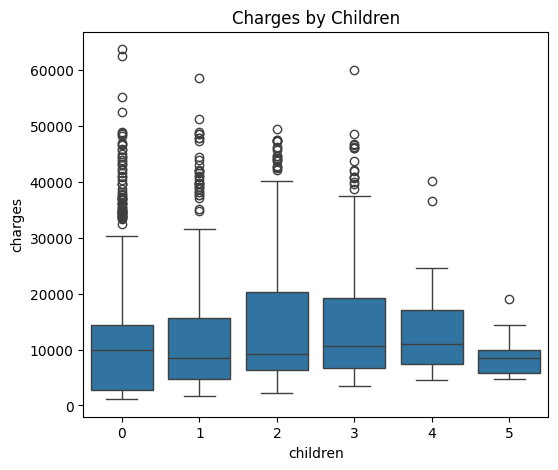

In [ ]:
# Box plot for 'charges' vs 'sex'
# I was assisted by chat GPT to generate the Box plots
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex')

# Box plot for 'charges' vs 'smoker'
plt.subplot(1, 3, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker')

# Box plot for 'charges' vs 'region'
plt.subplot(1, 3, 3)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')

plt.tight_layout()
plt.show()

# Box plot for 'charges' vs 'children'
plt.figure(figsize=(6, 5))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Charges by Children')
plt.show()

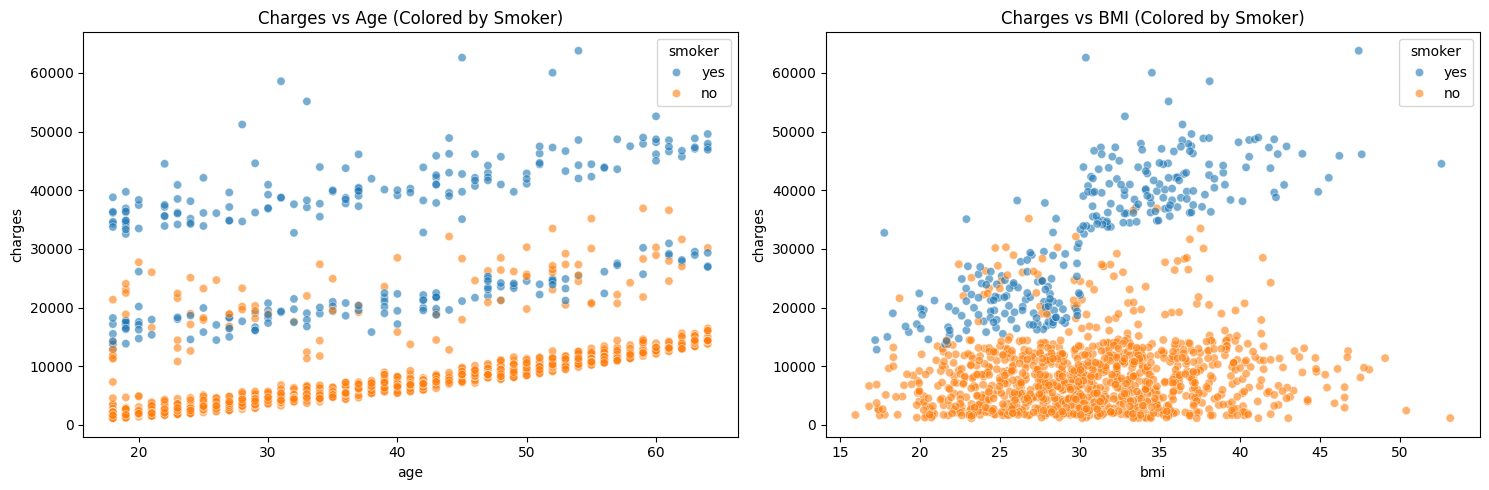

In [ ]:
# Scatter plot for 'age' vs 'charges'
# I was assisted by chat GPT to generate the Scatter plot
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', alpha=0.6)
plt.title('Charges vs Age (Colored by Smoker)')

# Scatter plot for 'bmi' vs 'charges'
plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', alpha=0.6)
plt.title('Charges vs BMI (Colored by Smoker)')

plt.tight_layout()
plt.show()

## Feature Selection



In [ ]:
# FEATURE SELECTION IMPORTS

from sklearn.feature_selection import VarianceThreshold

In [ ]:
# IDENTIFY CATEGORICAL VARIABLES
# These variables need to be encoded before
# applying feature selection methods

categorical_cols = ['sex', 'smoker', 'region']
print("Categorical columns:", categorical_cols)


Categorical columns: ['sex', 'smoker', 'region']


In [ ]:
# ONE-HOT ENCODING
# drop_first=True avoids the dummy variable trap,
# which is important for linear regression

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Verify encoding
display(df_encoded.head())
print("Shape after encoding:", df_encoded.shape)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Shape after encoding: (1337, 9)


In [ ]:
# SEPARATE FEATURES (X) AND TARGET (y)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Feature matrix shape (X):", X.shape)
print("Target variable shape (y):", y.shape)

Feature matrix shape (X): (1337, 8)
Target variable shape (y): (1337,)


In [ ]:
# VARIANCE-BASED FEATURE SELECTION
# Removes features with very low variability

# Initialize VarianceThreshold
# threshold=0.01 removes near-constant features
selector = VarianceThreshold(threshold=0.01)

# Fit and transform
X_reduced_variance = selector.fit_transform(X)

print("Original number of features:", X.shape[1])
print("Number of features after variance thresholding:", X_reduced_variance.shape[1])

Original number of features: 8
Number of features after variance thresholding: 8


In [ ]:
# RETRIEVE FEATURE NAMES AFTER VARIANCE FILTERING

selected_features_variance = X.columns[selector.get_support()]

print("Features retained after variance thresholding:")
print(selected_features_variance.tolist())

Features retained after variance thresholding:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [ ]:
# REBUILD DATAFRAME WITH SELECTED FEATURES

X_reduced_variance = pd.DataFrame(
    X_reduced_variance,
    columns=selected_features_variance,
    index=X.index
)

# Preview the reduced dataset
display(X_reduced_variance.head())

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,0.0,1.0,0.0,0.0,1.0
1,18.0,33.770,1.0,1.0,0.0,0.0,1.0,0.0
2,28.0,33.000,3.0,1.0,0.0,0.0,1.0,0.0
3,33.0,22.705,0.0,1.0,0.0,1.0,0.0,0.0
4,32.0,28.880,0.0,1.0,0.0,1.0,0.0,0.0


# Training the Linear Regression Model

In [ ]:
# MODEL TRAINING IMPORTS

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
# SPLIT DATA INTO TRAINING AND TEST SETS


X_train, X_test, y_train, y_test = train_test_split(
    X_reduced_variance,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1069, 8)
Test set shape: (268, 8)


In [ ]:
# INITIALISE AND TRAIN LINEAR REGRESSION MODEL


# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model using Ordinary Least Squares
lr_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:

# MAKE PREDICTIONS

y_pred = lr_model.predict(X_test)

# Preview predictions
display(pd.DataFrame({
    "Actual Charges": y_test.values[:5],
    "Predicted Charges": y_pred[:5]
}))

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657


In [ ]:
# MODEL EVALUATION

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.3f}")

Mean Squared Error (MSE): 35478020.68
Mean Absolute Error (MAE): 4177.05
R-squared (R²): 0.807


In [ ]:
# REGRESSION COEFFICIENTS

coefficients = pd.DataFrame({
    "Feature": X_reduced_variance.columns,
    "Coefficient": lr_model.coef_
})

display(coefficients.sort_values(by="Coefficient", ascending=False))

,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616
